[2000, 10000, 18000, 26000, 34000, 42000, 50000, 58000, 66000]


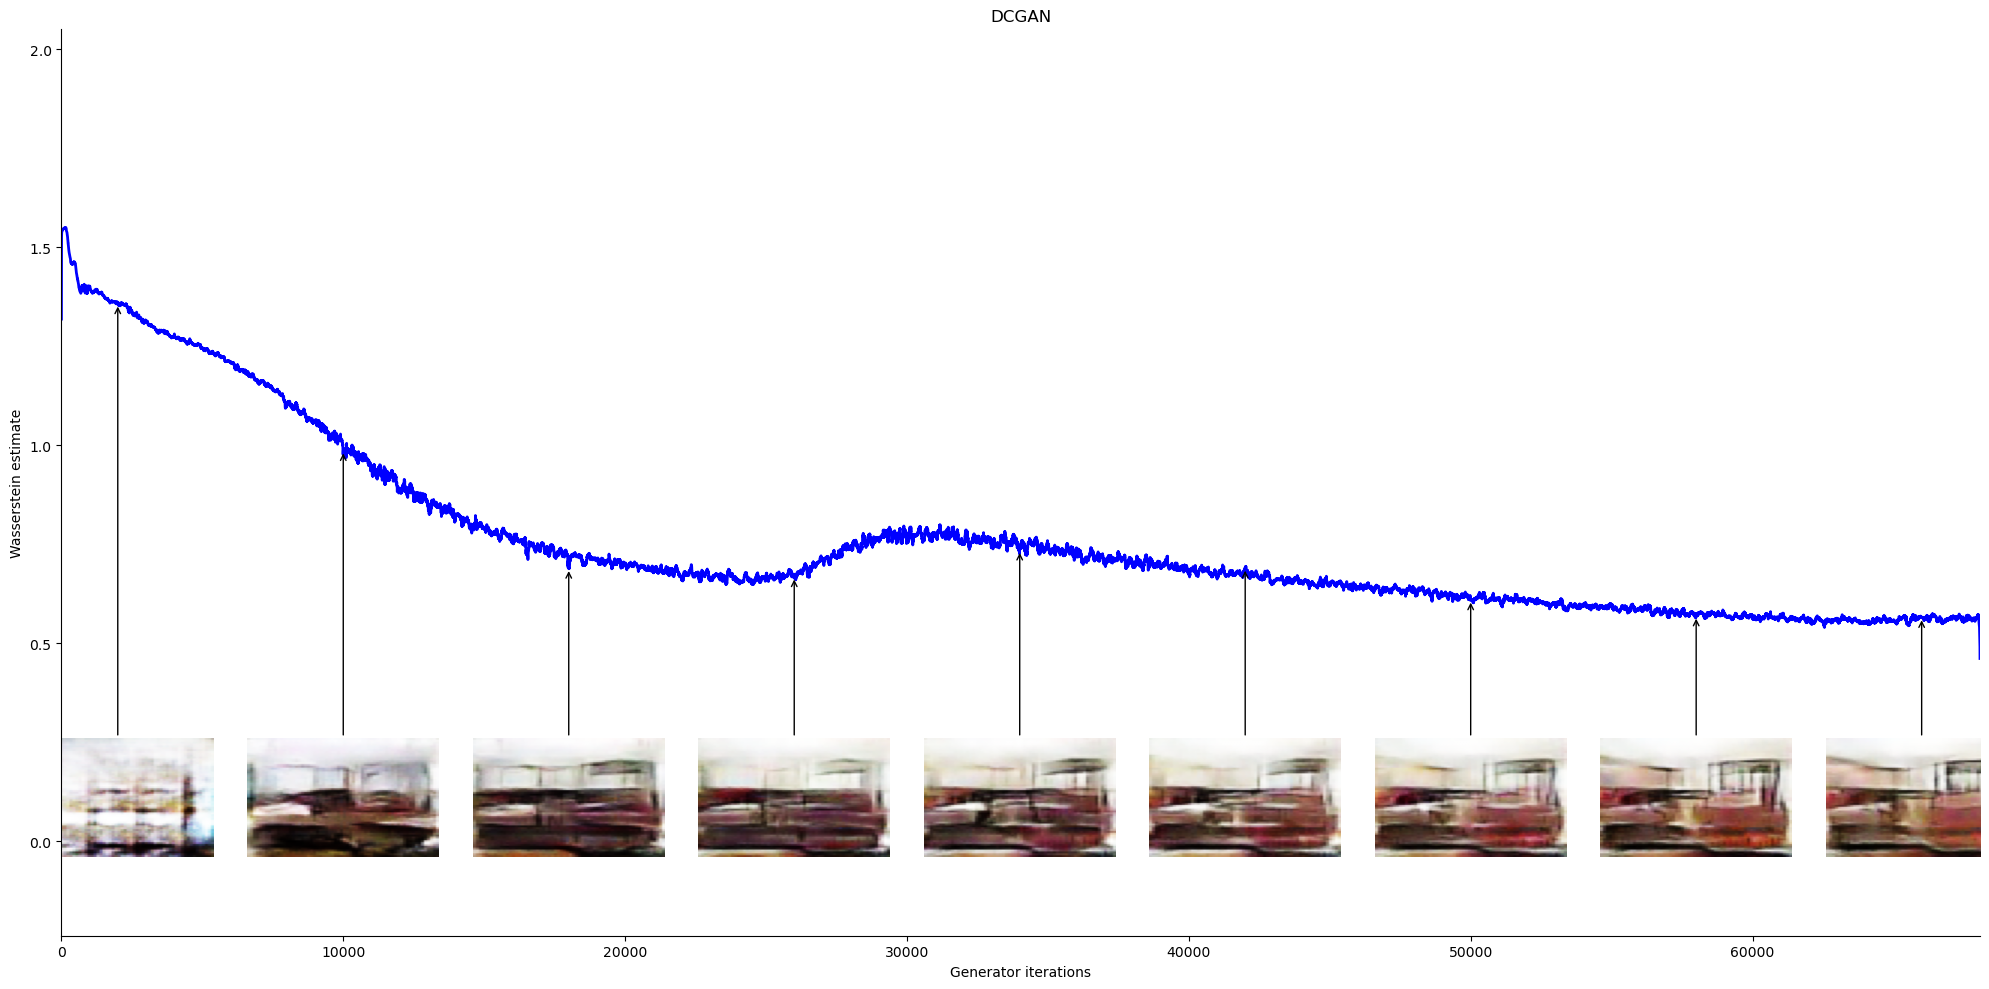

In [27]:
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from scipy.signal import medfilt
import os

# --- LOAD DATA ---
with open("v5/loss_log.json") as f:
    data = json.load(f)

iters = np.array(data["iterations"])
loss = np.array(data["loss_D"])

# IMPORTANT: negate + smooth
# kernel = max(5, len(loss)//100-1)
# loss = medfilt(-loss, kernel)
loss = medfilt(-loss, 101)   # no negative

plt.figure(figsize=(20,10))
plt.plot(iters, loss, color='blue', linewidth=2)

# --- SELECT ITERATIONS ---
points = []
for i in range(2000, 68000, 8000):
    points.append(i)
print(points)

y_img = min(loss) - 0.5

for p in points:
    img_path = f"v5/fake_samples_single_{p}.png"
    if os.path.exists(img_path):

        idx = np.argmin(np.abs(iters - p))
        y_curve = loss[idx]

        img = mpimg.imread(img_path)

        width = (iters[-1] - iters[0]) * 0.05

        plt.imshow(
            img,
            extent=(p - width, p + width, y_img, y_img + 0.3),
            aspect='auto'
        )

        plt.annotate(
            "",
            xy=(p, y_curve),
            xytext=(p, y_img + 0.3),
            arrowprops=dict(arrowstyle="->", color="black", lw=1)
        )

# --- AXIS STYLE ---
plt.xlabel("Generator iterations")
plt.ylabel("Wasserstein estimate")

plt.xlim(0, max(iters))
plt.ylim(y_img - 0.2, max(loss) + 0.5)

# clean look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title("DCGAN")

plt.tight_layout()
plt.show()